# M6-B1 — Analyse de dérive (à compléter)

In [21]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score

import sys

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src'))

from drift_detection import (
    chi2_pvalue,
    drift_report,
    ks_pvalue,
    population_stability_index,
)

from calibration import (reliability_table, expected_calibration_error)

In [22]:
REFERENCE_PATH = Path("../data/reference_set.csv")
PROD_PATH = Path("../data/prod_3months.csv")
OUTPUT_DIR = Path("../reports/reference_vs_prod_density")

MIN_UNIQUE_FOR_KDE = 10
HIST_BINS = 30
RANDOM_STATE = 42

## 1. Exploration — distributions référence vs prod

In [8]:
def load_datasets(reference_path: Path, prod_path: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    reference = pd.read_csv(reference_path)
    prod = pd.read_csv(prod_path)

    if "timestamp" in prod.columns:
        prod["timestamp"] = pd.to_datetime(prod["timestamp"], errors="coerce")

    return reference, prod


def get_numeric_columns(reference: pd.DataFrame, prod: pd.DataFrame) -> list[str]:
    common_cols = sorted(set(reference.columns) & set(prod.columns))
    numeric_cols = []

    for col in common_cols:
        if pd.api.types.is_numeric_dtype(reference[col]) and pd.api.types.is_numeric_dtype(prod[col]):
            numeric_cols.append(col)

    return numeric_cols


def split_continuous_and_discrete(
    reference: pd.DataFrame,
    prod: pd.DataFrame,
    numeric_cols: list[str],
) -> tuple[list[str], list[str]]:
    continuous_cols = []
    discrete_cols = []

    for col in numeric_cols:
        ref_unique = reference[col].dropna().nunique()
        prod_unique = prod[col].dropna().nunique()
        max_unique = max(ref_unique, prod_unique)

        if max_unique >= MIN_UNIQUE_FOR_KDE:
            continuous_cols.append(col)
        else:
            discrete_cols.append(col)

    return continuous_cols, discrete_cols


def ensure_output_dirs(base_dir: Path) -> dict[str, Path]:
    paths = {
        "base": base_dir,
        "continuous": base_dir / "continuous",
        "discrete": base_dir / "discrete",
        "summary": base_dir / "summary",
    }
    for path in paths.values():
        path.mkdir(parents=True, exist_ok=True)
    return paths


def numeric_shift_summary(reference: pd.Series, prod: pd.Series) -> dict[str, float]:
    ref = reference.dropna()
    cur = prod.dropna()

    ref_mean = ref.mean()
    cur_mean = cur.mean()
    ref_median = ref.median()
    cur_median = cur.median()
    ref_std = ref.std(ddof=0)

    mean_shift = np.nan
    median_shift = np.nan

    if pd.notna(ref_std) and ref_std > 0:
        mean_shift = abs(cur_mean - ref_mean) / ref_std
        median_shift = abs(cur_median - ref_median) / ref_std

    q01 = ref.quantile(0.01) if not ref.empty else np.nan
    q99 = ref.quantile(0.99) if not ref.empty else np.nan

    outside_ref_band = np.nan
    if pd.notna(q01) and pd.notna(q99) and not cur.empty:
        outside_ref_band = ((cur < q01) | (cur > q99)).mean()

    return {
        "ref_mean": ref_mean,
        "prod_mean": cur_mean,
        "ref_median": ref_median,
        "prod_median": cur_median,
        "ref_std": ref_std,
        "mean_shift_zscore": mean_shift,
        "median_shift_zscore": median_shift,
        "prod_outside_ref_1_99_band_rate": outside_ref_band,
        "ref_missing_rate": reference.isna().mean(),
        "prod_missing_rate": prod.isna().mean(),
    }


def plot_continuous_density(
    reference: pd.DataFrame,
    prod: pd.DataFrame,
    col: str,
    out_dir: Path | None = None,
    save: bool = False,
) -> dict[str, float | str]:
    ref = reference[col].dropna()
    cur = prod[col].dropna()

    summary = numeric_shift_summary(reference[col], prod[col])

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

    combined = pd.concat([ref, cur], ignore_index=True)
    common_bins = np.histogram_bin_edges(combined, bins=HIST_BINS)

    axes[0].hist(ref, bins=common_bins, density=True, alpha=0.45, color="#1f77b4", edgecolor="white", label="reference")
    axes[0].hist(cur, bins=common_bins, density=True, alpha=0.45, color="#ff7f0e", edgecolor="white", label="prod")
    axes[0].set_title(f"{col} - histogrammes normalises")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("densite")
    axes[0].legend()

    ref.plot(kind="kde", ax=axes[1], color="#1f77b4", linewidth=2, label="reference")
    cur.plot(kind="kde", ax=axes[1], color="#ff7f0e", linewidth=2, label="prod")
    axes[1].set_title(f"{col} - densites superposees")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("densite")
    axes[1].legend()

    plt.tight_layout()
    if save and out_dir is not None:
        fig.savefig(out_dir / f"{col}.png", dpi=150)
    plt.show()

    return {
        "feature": col,
        "type": "continuous_numeric",
        **summary,
    }


def plot_discrete_comparison(
    reference: pd.DataFrame,
    prod: pd.DataFrame,
    col: str,
    out_dir: Path | None = None,
    save: bool = False,
) -> dict[str, float | str]:
    ref = reference[col].fillna("MISSING")
    cur = prod[col].fillna("MISSING")

    ref_prop = ref.value_counts(normalize=True).sort_index()
    cur_prop = cur.value_counts(normalize=True).sort_index()
    values = sorted(set(ref_prop.index) | set(cur_prop.index))

    ref_prop = ref_prop.reindex(values, fill_value=0.0)
    cur_prop = cur_prop.reindex(values, fill_value=0.0)

    fig, ax = plt.subplots(figsize=(9, 4.5))
    x = np.arange(len(values))
    width = 0.4

    ax.bar(
        x - width / 2,
        ref_prop.values,
        width=width,
        color="#1f77b4",
        alpha=0.8,
        label="reference",
    )
    ax.bar(
        x + width / 2,
        cur_prop.values,
        width=width,
        color="#ff7f0e",
        alpha=0.8,
        label="prod",
    )

    ax.set_title(f"{col} - proportions par valeur")
    ax.set_xlabel(col)
    ax.set_ylabel("proportion")
    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in values], rotation=45, ha="right")
    ax.legend()

    plt.tight_layout()
    if save and out_dir is not None:
        fig.savefig(out_dir / f"{col}.png", dpi=150)
    plt.show()

    return {
        "feature": col,
        "type": "discrete_numeric",
        "max_share_delta": (cur_prop - ref_prop).abs().max(),
        "ref_missing_rate": reference[col].isna().mean(),
        "prod_missing_rate": prod[col].isna().mean(),
    }

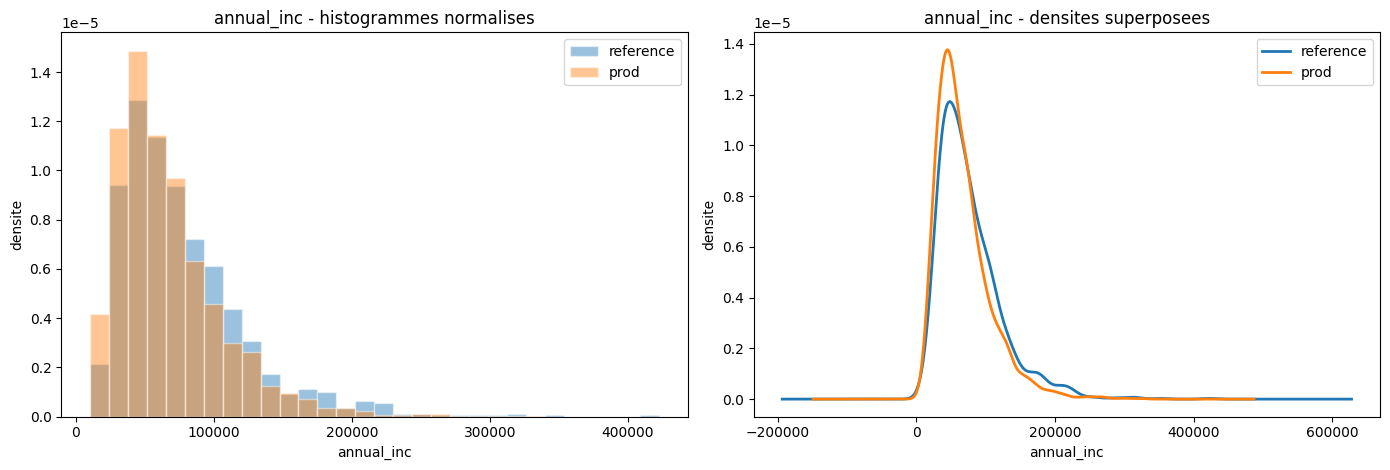

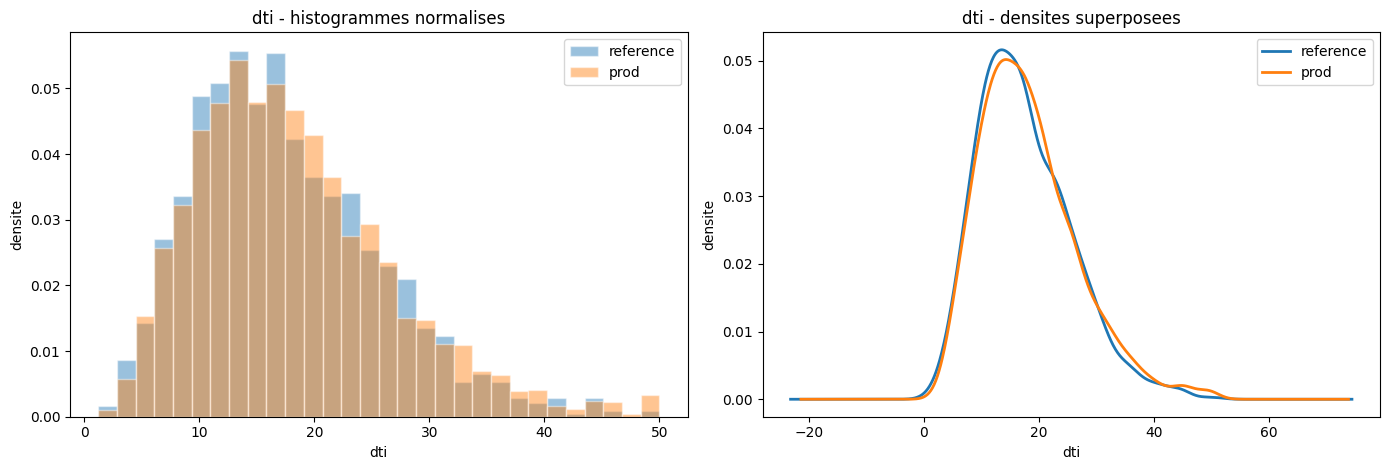

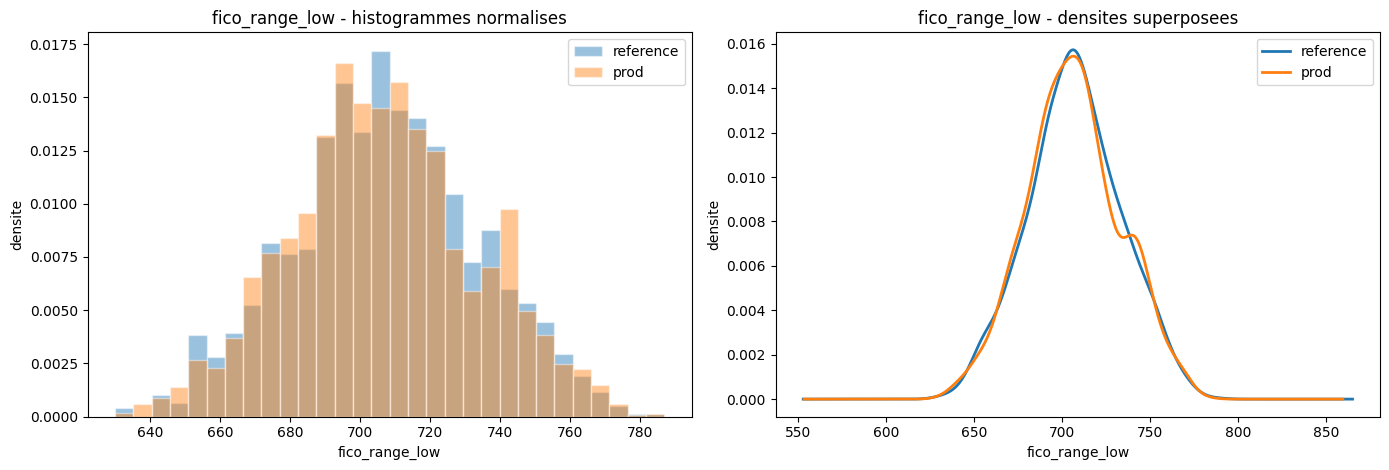

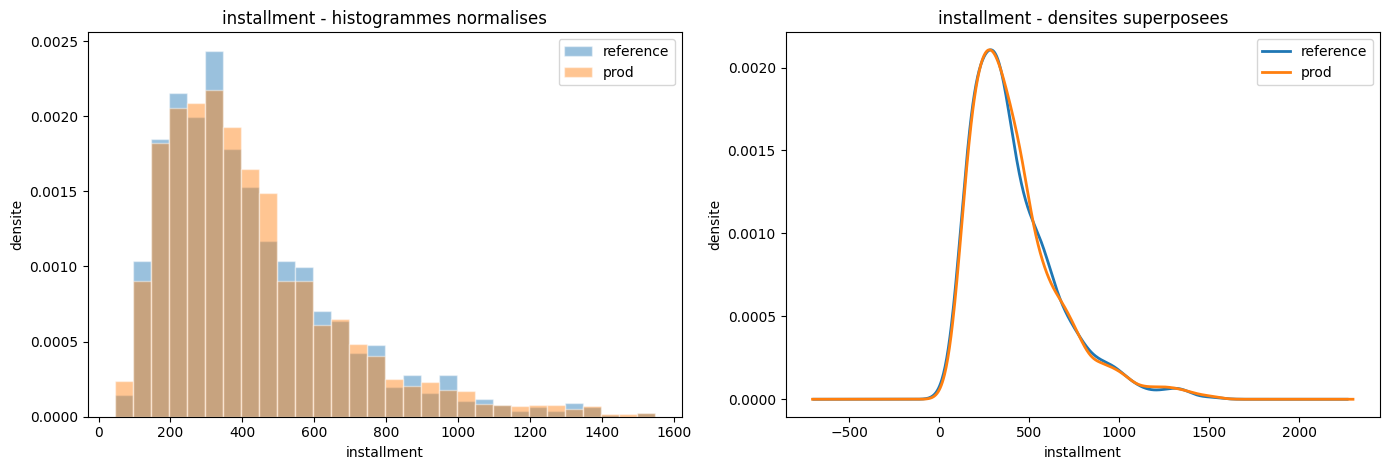

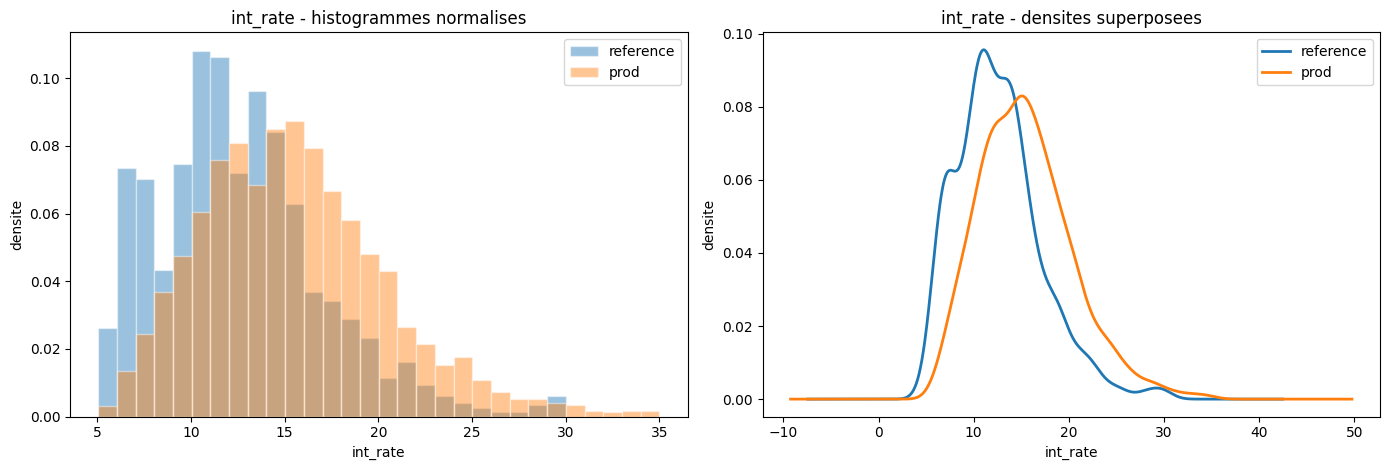

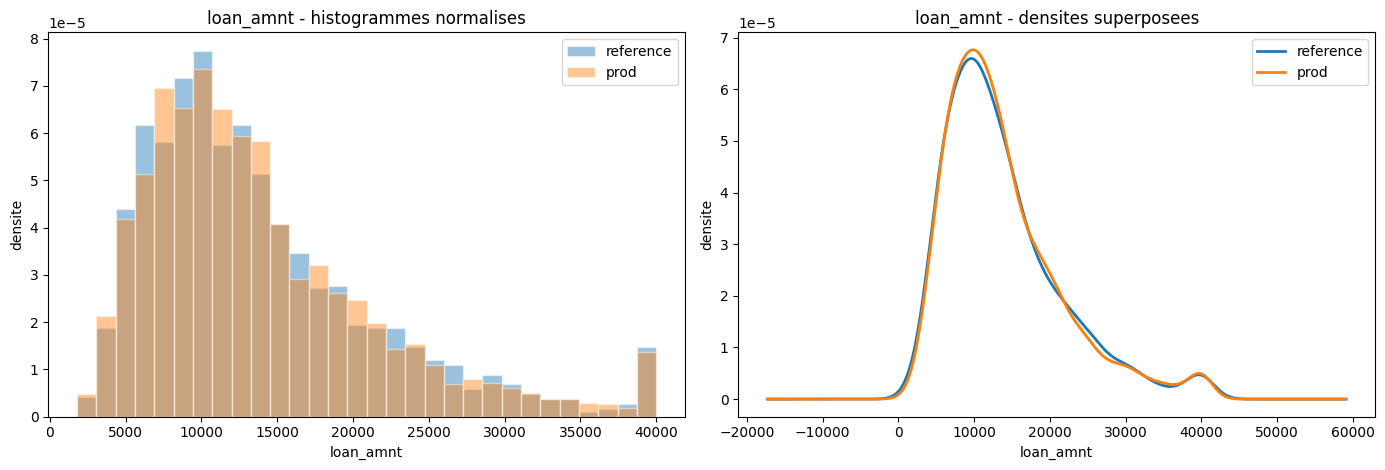

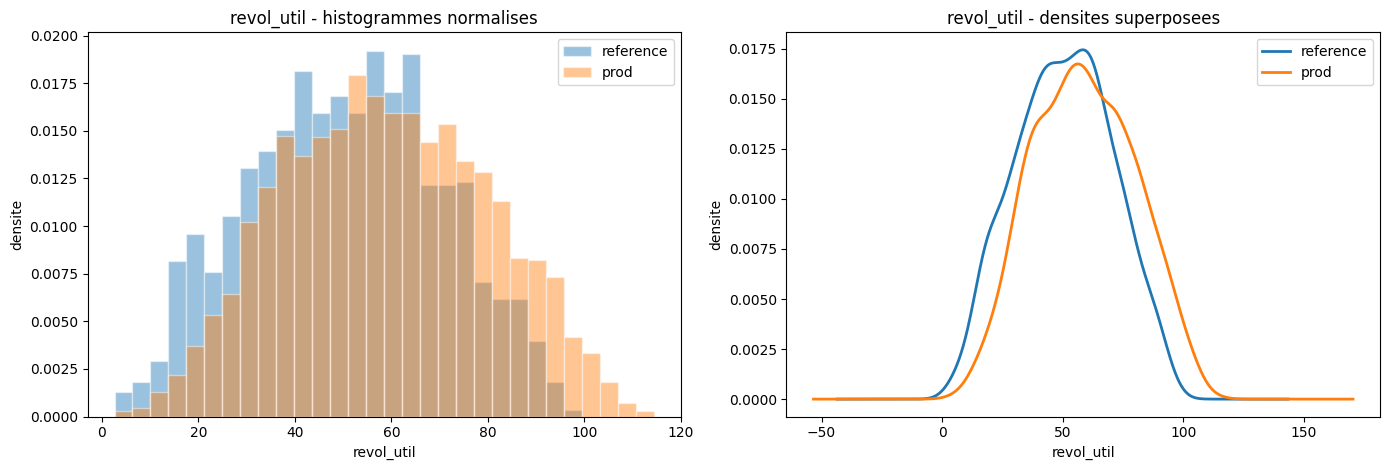

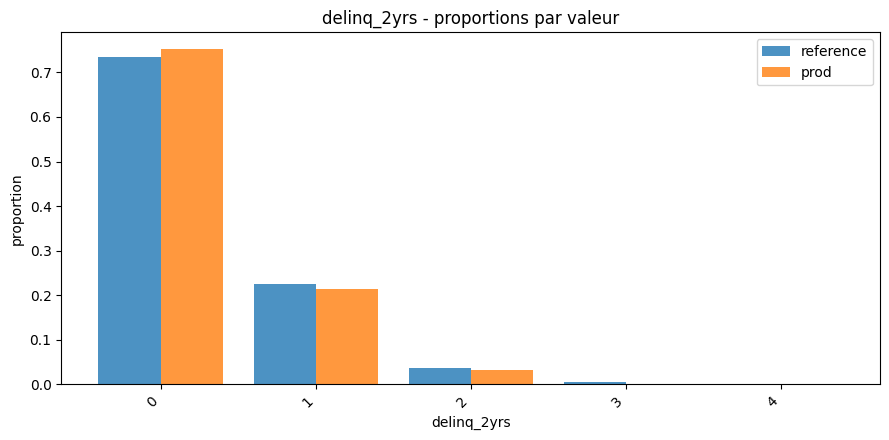

In [ ]:
paths = ensure_output_dirs(OUTPUT_DIR)
reference, prod = load_datasets(REFERENCE_PATH, PROD_PATH)

numeric_cols = get_numeric_columns(reference, prod)
continuous_cols, discrete_cols = split_continuous_and_discrete(reference, prod, numeric_cols)

continuous_results = []
for col in continuous_cols:
    continuous_results.append(
        plot_continuous_density(reference, prod, col, paths["continuous"])
    )

discrete_results = []
for col in discrete_cols:
    discrete_results.append(
        plot_discrete_comparison(reference, prod, col, paths["discrete"])
    )

In [ ]:
print("Comparaison reference vs prod terminee")
print(f"Variables continues tracees: {len(continuous_cols)}")
print(f"Variables discretes tracees: {len(discrete_cols)}")

Comparaison reference vs prod terminee
Sortie: D:\Projets\FormationSimplon\Briefs\M6-B1-pyrenex-drift-Romain-JulienD\reports\reference_vs_prod_density
Variables continues tracees: 7
Variables discretes tracees: 1


# Conclusion

En observant les courbes on remarque les éléments suivants :
- la distribution du revenu s'est légèrement déplacée vers la gauche indiquant une baisse des revenus entre la réference et la production
- la distribution du taux d'emprunt s'est déplacée significativement vers la droite indiquant une augmentation des taux d'intérêts
- la distribution de l'indicateur revol_util s'est déplacé vers la droite : il y a une augmentation du crédit à la consommation ou tout du moins de l'indicateur qui le mesure
- On constate que le defaut de paiement est légèrement inférieur dans les données de production que dans les données de références. Ce qui est étonnant au regard de la dégradation des indicateurs précédemment évoqués

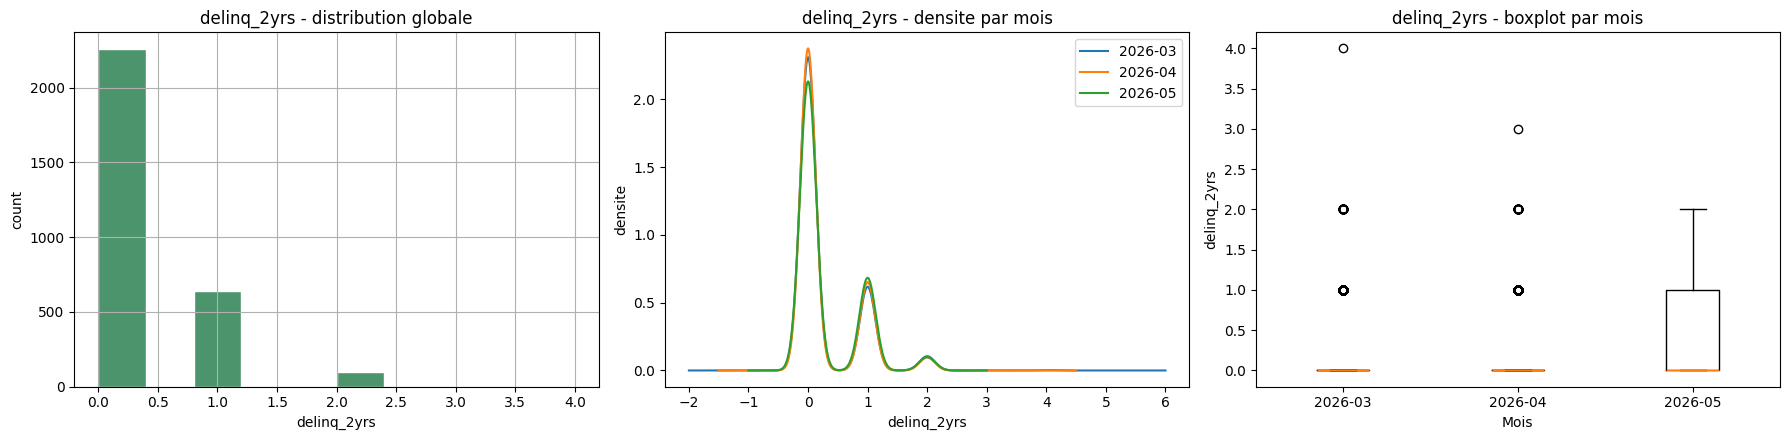

In [12]:
df = pd.read_csv("../data/prod_3months.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df["month"] = df["timestamp"].dt.to_period("M").astype(str)

col = "delinq_2yrs"
months = sorted(df["month"].dropna().unique())

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

df[col].dropna().hist(
    ax=axes[0],
    bins=10,
    color="#4c956c",
    edgecolor="white",
)
axes[0].set_title(f"{col} - distribution globale")
axes[0].set_xlabel(col)
axes[0].set_ylabel("count")

for month, group in df.groupby("month"):
    group[col].dropna().plot(
        kind="kde",
        ax=axes[1],
        label=month,
    )

axes[1].set_title(f"{col} - densite par mois")
axes[1].set_xlabel(col)
axes[1].set_ylabel("densite")
axes[1].legend()

box_data = [
    df.loc[df["month"] == month, col].dropna()
    for month in months
]

axes[2].boxplot(
    box_data,
    tick_labels=months,
    showfliers=True,
)
axes[2].set_title(f"{col} - boxplot par mois")
axes[2].set_xlabel("Mois")
axes[2].set_ylabel(col)

plt.tight_layout()
plt.show()

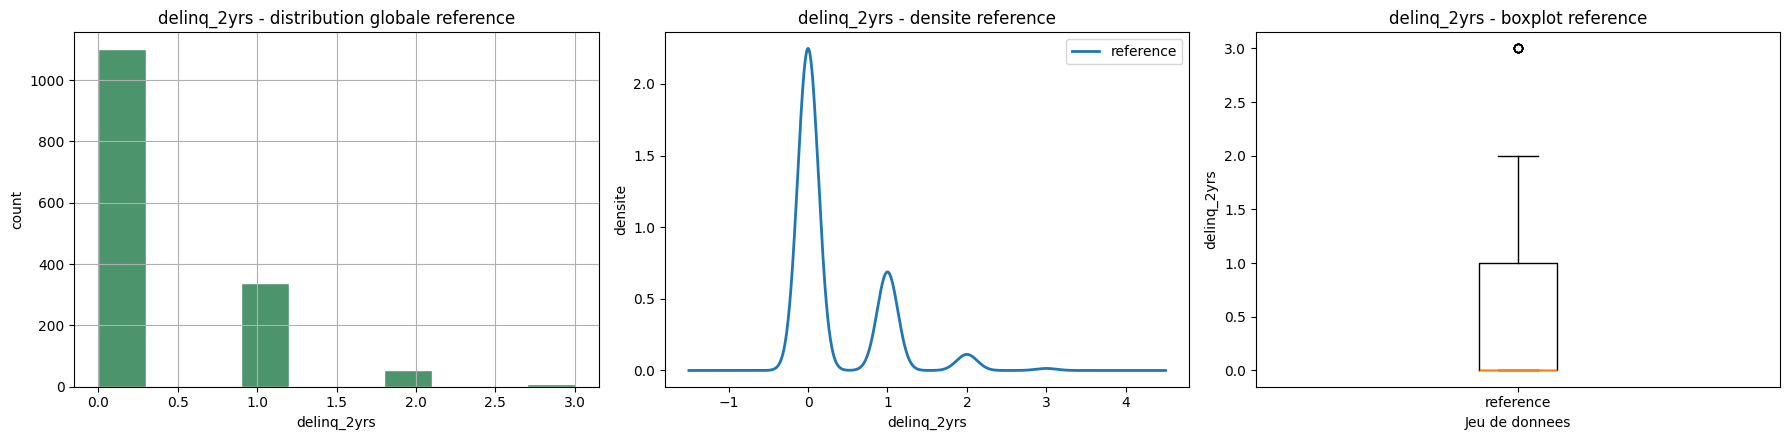

In [13]:
df_ref = pd.read_csv("../data/reference_set.csv")

col = "delinq_2yrs"

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

df_ref[col].dropna().hist(
    ax=axes[0],
    bins=10,
    color="#4c956c",
    edgecolor="white",
)
axes[0].set_title(f"{col} - distribution globale reference")
axes[0].set_xlabel(col)
axes[0].set_ylabel("count")

df_ref[col].dropna().plot(
    kind="kde",
    ax=axes[1],
    color="#1f77b4",
    linewidth=2,
    label="reference",
)
axes[1].set_title(f"{col} - densite reference")
axes[1].set_xlabel(col)
axes[1].set_ylabel("densite")
axes[1].legend()

axes[2].boxplot(
    [df_ref[col].dropna()],
    tick_labels=["reference"],
    showfliers=True,
)
axes[2].set_title(f"{col} - boxplot reference")
axes[2].set_xlabel("Jeu de donnees")
axes[2].set_ylabel(col)

plt.tight_layout()
plt.show()

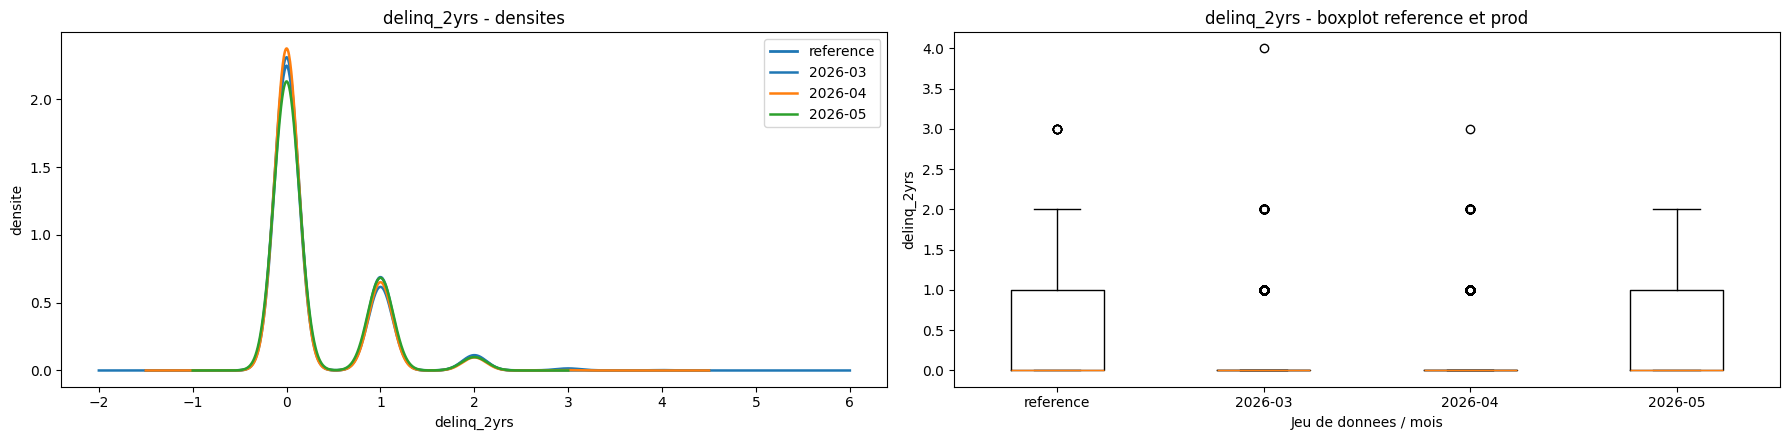

In [ ]:
col = "delinq_2yrs"
months = sorted(df["month"].dropna().unique())

ref_series = df_ref[col].dropna()
prod_series = df[col].dropna()
prod_by_month = [df.loc[df["month"] == month, col].dropna() for month in months]

fig, axes = plt.subplots(1, 2, figsize=(18, 4.5))

all_values = pd.concat([ref_series, prod_series], ignore_index=True)
common_bins = np.histogram_bin_edges(all_values, bins=10)

ref_series.plot(
    kind="kde",
    ax=axes[0],
    color="#1f77b4",
    linewidth=2,
    label="reference",
)
for month in months:
    df.loc[df["month"] == month, col].dropna().plot(
        kind="kde",
        ax=axes[0],
        linewidth=1.8,
        label=month,
    )
axes[0].set_title(f"{col} - densites")
axes[0].set_xlabel(col)
axes[0].set_ylabel("densite")
axes[0].legend()

axes[1].boxplot(
    [ref_series, *prod_by_month],
    tick_labels=["reference", *months],
    showfliers=True,
)
axes[1].set_title(f"{col} - boxplot reference et prod")
axes[1].set_xlabel("Jeu de donnees / mois")
axes[1].set_ylabel(col)

plt.tight_layout()
plt.show()

### Zoom defaut de paiement

On constate que la donnée varie dans la période d'analyse de la production : le nombre de défaut augmente au mois de mai par rapport à mars et avril.
La distribution des données de référence semblent correspondre à la distribution des données du mois de mai.

## 2. Détection statistique — PSI · KS · Chi²

In [ ]:
reference = pd.read_csv(ROOT / 'data' / 'reference_set.csv')
prod = pd.read_csv(ROOT / 'data' / 'prod_3months.csv')

common_features = [col for col in reference.columns if col in prod.columns]
excluded_columns = []
feature_cols = [col for col in common_features if col not in excluded_columns]

numeric_features = reference[feature_cols].select_dtypes(include='number').columns.tolist()
categorical_features = [col for col in feature_cols if col not in numeric_features]

print(f'Features numeriques analysees : {numeric_features}')
print(f'Features categorielles analysees : {categorical_features}')

# Calculs detailles
for feature in numeric_features:
    psi = population_stability_index(reference[feature], prod[feature])
    p_value = ks_pvalue(reference[feature], prod[feature])
    print(f'{feature} | PSI = {psi:.3f} | KS p-value = {p_value:.3g}')

for feature in categorical_features:
    p_value = chi2_pvalue(reference[feature], prod[feature])
    print(f'{feature} | Chi2 p-value = {p_value:.3g}')

summary = drift_report(
    reference,
    prod,
    numeric_cols=numeric_features,
    categorical_cols=categorical_features,
)

summary_display = summary.copy()
summary_display['PSI'] = summary_display['PSI'].map(lambda value: '-' if pd.isna(value) else f'{value:.3f}')
summary_display['p-value'] = summary_display['p-value'].map(
    lambda value: '-' if pd.isna(value) else ('< 0.001' if value < 0.001 else f'{value:.3f}')
)

display(summary_display[['Feature', 'Type', 'PSI', 'p-value', 'Verdict', 'Commentaire']])

Features numeriques analysees : ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'revol_util']
Features categorielles analysees : ['term', 'grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'loan_status']
loan_amnt | PSI = 0.003 | KS p-value = 0.989
int_rate | PSI = 0.444 | KS p-value = 4.63e-65
installment | PSI = 0.015 | KS p-value = 0.663
annual_inc | PSI = 0.067 | KS p-value = 2.28e-09
dti | PSI = 0.011 | KS p-value = 0.11
delinq_2yrs | PSI = 0.002 | KS p-value = 0.888
fico_range_low | PSI = 0.007 | KS p-value = 0.489
revol_util | PSI = 0.187 | KS p-value = 3.82e-20
term | Chi2 p-value = 0.316
grade | Chi2 p-value = 3.65e-07
emp_length | Chi2 p-value = 0.529
home_ownership | Chi2 p-value = 0.631
verification_status | Chi2 p-value = 0.586
purpose | Chi2 p-value = 0.199
loan_status | Chi2 p-value = 0.215


,Feature,Type,PSI,p-value,Verdict,Commentaire
0,loan_amnt,numérique,0.003,0.989,stable,pas de signal
1,int_rate,numérique,0.444,< 0.001,dérive forte,signaux concordants
2,installment,numérique,0.015,0.663,stable,pas de signal
3,annual_inc,numérique,0.067,< 0.001,stable,écart détectable mais faible
4,dti,numérique,0.011,0.110,stable,pas de signal
5,delinq_2yrs,numérique,0.002,0.888,stable,pas de signal
6,fico_range_low,numérique,0.007,0.489,stable,pas de signal
7,revol_util,numérique,0.187,< 0.001,suspect,à investiguer
8,term,catégorielle,-,0.316,stable,pas de signal
9,grade,catégorielle,-,< 0.001,dérive,modalités redistribuées


### Conclusion

Le jeu de production reste globalement proche du jeu de référence sur la majorité des variables : `loan_amnt`, `installment`, `dti`, `delinq_2yrs`, `fico_range_low` et la plupart des variables catégorielles ne montrent pas de signal de dérive.

En revanche, `int_rate` présente une dérive forte : le PSI est élevé (`0.444 > 0.25`) et le test KS est très significatif (`p-value < 0.001`). Les deux signaux concordent, ce qui indique un changement important de distribution sur le taux d'intérêt.

Deux autres signaux doivent être surveillés : `revol_util` est suspect (`PSI = 0.187`, p-value `< 0.001`), et `grade` montre une redistribution significative des modalités (`Chi² p-value < 0.001`). `annual_inc` a une p-value significative, mais un PSI faible (`0.067`), donc l'écart est détectable statistiquement mais son ampleur reste limitée.

## 3. Calibration en exploitation

In [27]:
pred = pd.read_csv("../data/predictions_log.csv")
pred["timestamp"] = pd.to_datetime(pred["timestamp"], errors="coerce")

pred = pred.sort_values("timestamp").copy()

start_date = pred["timestamp"].min()
pred["week_index"] = ((pred["timestamp"] - start_date).dt.days // 7) + 1

pred_w1_4 = pred[pred["week_index"].between(1, 4)]
pred_w9_12 = pred[pred["week_index"].between(9, 12)]

auc_w1_4 = roc_auc_score(pred_w1_4["true_label"], pred_w1_4["proba_default"])
auc_w9_12 = roc_auc_score(pred_w9_12["true_label"], pred_w9_12["proba_default"])
delta_auc = auc_w9_12 - auc_w1_4

print(f"AUC semaines 1-4  : {auc_w1_4:.4f}")
print(f"AUC semaines 9-12 : {auc_w9_12:.4f}")
print(f"Delta AUC         : {delta_auc:+.4f}")

if abs(delta_auc) < 0.03:
    print("AUC globalement stable -> compatible avec un data drift")
else:
    print("AUC en variation notable -> concept drift a investiguer")

AUC semaines 1-4  : 0.7419
AUC semaines 9-12 : 0.7459
Delta AUC         : +0.0040
AUC globalement stable -> compatible avec un data drift


In [33]:
table_debut = reliability_table(pred_w1_4["proba_default"], pred_w1_4["true_label"], n_bins=10)
table_fin = reliability_table(pred_w9_12["proba_default"], pred_w9_12["true_label"], n_bins=10)

ece_debut = expected_calibration_error(pred_w1_4["proba_default"], pred_w1_4["true_label"], n_bins=10)
ece_fin = expected_calibration_error(pred_w9_12["proba_default"], pred_w9_12["true_label"], n_bins=10)

print("table debut : ") 
display(table_debut)
print("ece debut : ") 
display(ece_debut)
print("table fin : ") 
display(table_fin)
print("ece fin : ") 
display(ece_fin)

table debut : 


,bin,n,confiance_moyenne,taux_observe,ecart
0,"(-0.001, 0.1]",16,0.081656,0.000000,0.081656
1,"(0.1, 0.2]",81,0.157801,0.012346,0.145456
2,"(0.2, 0.3]",136,0.252366,0.051471,0.200896
3,"(0.3, 0.4]",175,0.351959,0.131429,0.220531
4,"(0.4, 0.5]",176,0.451441,0.164773,0.286669
5,"(0.5, 0.6]",229,0.550891,0.283843,0.267048
6,"(0.6, 0.7]",123,0.640639,0.333333,0.307306
7,"(0.7, 0.8]",63,0.734944,0.539683,0.195262
8,"(0.8, 0.9]",4,0.822425,0.750000,0.072425


ece debut : 


0.24027986041874377

table fin : 


,bin,n,confiance_moyenne,taux_observe,ecart
0,"(0.1, 0.2]",15,0.166533,0.000000,0.166533
1,"(0.2, 0.3]",75,0.259519,0.026667,0.232852
2,"(0.3, 0.4]",128,0.349095,0.031250,0.317845
3,"(0.4, 0.5]",213,0.450442,0.107981,0.342461
4,"(0.5, 0.6]",273,0.554366,0.205128,0.349237
5,"(0.6, 0.7]",170,0.644754,0.341176,0.303577
6,"(0.7, 0.8]",120,0.735706,0.458333,0.277373
7,"(0.8, 0.9]",3,0.815600,0.666667,0.148933


ece fin : 


0.3152172517552658

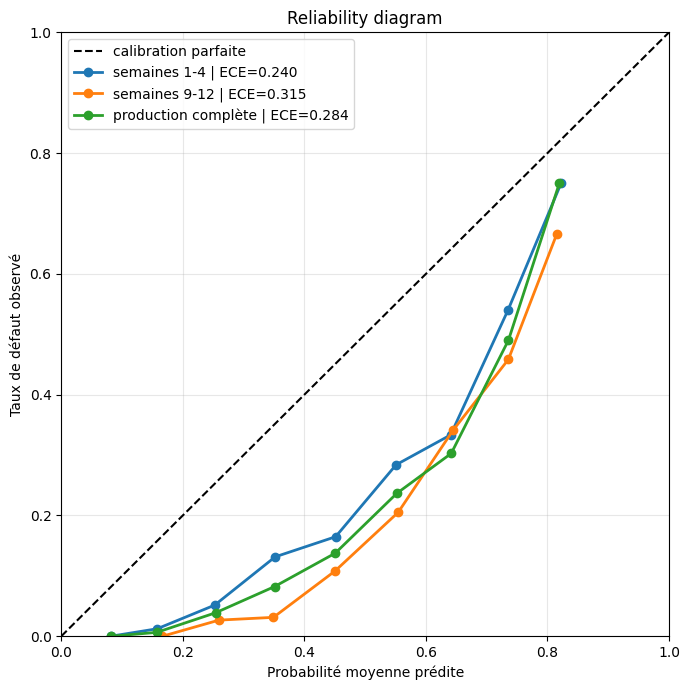

,periode,bin,n,confiance_moyenne,taux_observe,biais,interpretation
0,semaines 1-4,"(-0.001, 0.1]",16,0.082,0.000,-0.082,surestime le risque
1,semaines 1-4,"(0.1, 0.2]",81,0.158,0.012,-0.145,surestime le risque
2,semaines 1-4,"(0.2, 0.3]",136,0.252,0.051,-0.201,surestime le risque
3,semaines 1-4,"(0.3, 0.4]",175,0.352,0.131,-0.221,surestime le risque
4,semaines 1-4,"(0.4, 0.5]",176,0.451,0.165,-0.287,surestime le risque
5,semaines 1-4,"(0.5, 0.6]",229,0.551,0.284,-0.267,surestime le risque
6,semaines 1-4,"(0.6, 0.7]",123,0.641,0.333,-0.307,surestime le risque
7,semaines 1-4,"(0.7, 0.8]",63,0.735,0.540,-0.195,surestime le risque
8,semaines 1-4,"(0.8, 0.9]",4,0.822,0.750,-0.072,surestime le risque
9,semaines 9-12,"(0.1, 0.2]",15,0.167,0.000,-0.167,surestime le risque


In [25]:
# reliability diagram, le modèle est-il sur/sous-confiant par rapport à la réalité
pred = pd.read_csv("../data/predictions_log.csv")
pred["timestamp"] = pd.to_datetime(pred["timestamp"], errors="coerce")
pred = pred.sort_values("timestamp").copy()

start_date = pred["timestamp"].min()
pred["week_index"] = ((pred["timestamp"] - start_date).dt.days // 7) + 1

pred_w1_4 = pred[pred["week_index"].between(1, 4)]
pred_w9_12 = pred[pred["week_index"].between(9, 12)]

calibration_sets = {
    "semaines 1-4": pred_w1_4,
    "semaines 9-12": pred_w9_12,
    "production complète": pred,
}

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1.5, label="calibration parfaite")

reliability_tables = {}
for label, data in calibration_sets.items():
    table = reliability_table(data["proba_default"], data["true_label"], n_bins=10)
    table["periode"] = label
    table["biais"] = table["taux_observe"] - table["confiance_moyenne"]
    table["interpretation"] = np.where(
        table["biais"] > 0,
        "sous-estime le risque",
        np.where(table["biais"] < 0, "surestime le risque", "calibre"),
    )
    reliability_tables[label] = table

    ax.plot(
        table["confiance_moyenne"],
        table["taux_observe"],
        marker="o",
        linewidth=2,
        label=f"{label} | ECE={expected_calibration_error(data['proba_default'], data['true_label'], n_bins=10):.3f}",
    )

ax.set_title("Reliability diagram")
ax.set_xlabel("Probabilité moyenne prédite")
ax.set_ylabel("Taux de défaut observé")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

calibration_summary = pd.concat(reliability_tables.values(), ignore_index=True)
calibration_summary_display = calibration_summary[[
    "periode",
    "bin",
    "n",
    "confiance_moyenne",
    "taux_observe",
    "biais",
    "interpretation",
]].copy()

for col in ["confiance_moyenne", "taux_observe", "biais"]:
    calibration_summary_display[col] = calibration_summary_display[col].round(3)

display(calibration_summary_display)

Le reliability diagram montre que les courbes sont majoritairement sous la diagonale de calibration parfaite. Cela signifie que, pour une probabilité prédite donnée, le taux de défaut observé est plus faible que la probabilité annoncée par le modèle. Le modèle surestime donc le risque de défaut : il est sur-confiant dans la classe "défaut".

Cette mauvaise calibration est plus marquée en fin de période, avec un ECE qui augmente entre les semaines 1-4 et les semaines 9-12. Cela suggère une dégradation de calibration en production, probablement liée au drift observé sur certaines variables comme `int_rate`, `revol_util` et `grade`.

## 4. Performance dans le temps

In [36]:
pred = pd.read_csv("../data/predictions_log.csv")
pred["timestamp"] = pd.to_datetime(pred["timestamp"], errors="coerce")
pred = pred.sort_values("timestamp").copy()

start_date = pred["timestamp"].min()
pred["week_index"] = ((pred["timestamp"] - start_date).dt.days // 7) + 1

weekly_perf = (
    pred.groupby("week_index")
    .apply(
        lambda g: pd.Series({
            "n": len(g),
            "auc": roc_auc_score(g["true_label"], g["proba_default"]),
            "f1": f1_score(g["true_label"], g["prediction"], average="macro"),
            "default_rate": g["true_label"].mean(),
            "mean_score": g["proba_default"].mean(),
        })
    )
    .reset_index()
)

display(weekly_perf)


C:\Users\hsuty\AppData\Local\Temp\ipykernel_31804\34492124.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,week_index,n,auc,f1,default_rate,mean_score
0,1,226.0,0.716351,0.610853,0.212389,0.435980
1,2,293.0,0.777211,0.621531,0.163823,0.418530
2,3,236.0,0.737675,0.602600,0.241525,0.461308
3,4,248.0,0.720909,0.590767,0.201613,0.459561
4,5,234.0,0.739908,0.575299,0.166667,0.451901
5,6,269.0,0.726712,0.552696,0.185874,0.471057
6,7,254.0,0.716962,0.555740,0.169291,0.469165
7,8,243.0,0.759301,0.571893,0.160494,0.482732
8,9,233.0,0.798033,0.607394,0.214592,0.505179
9,10,248.0,0.756731,0.518055,0.161290,0.509204


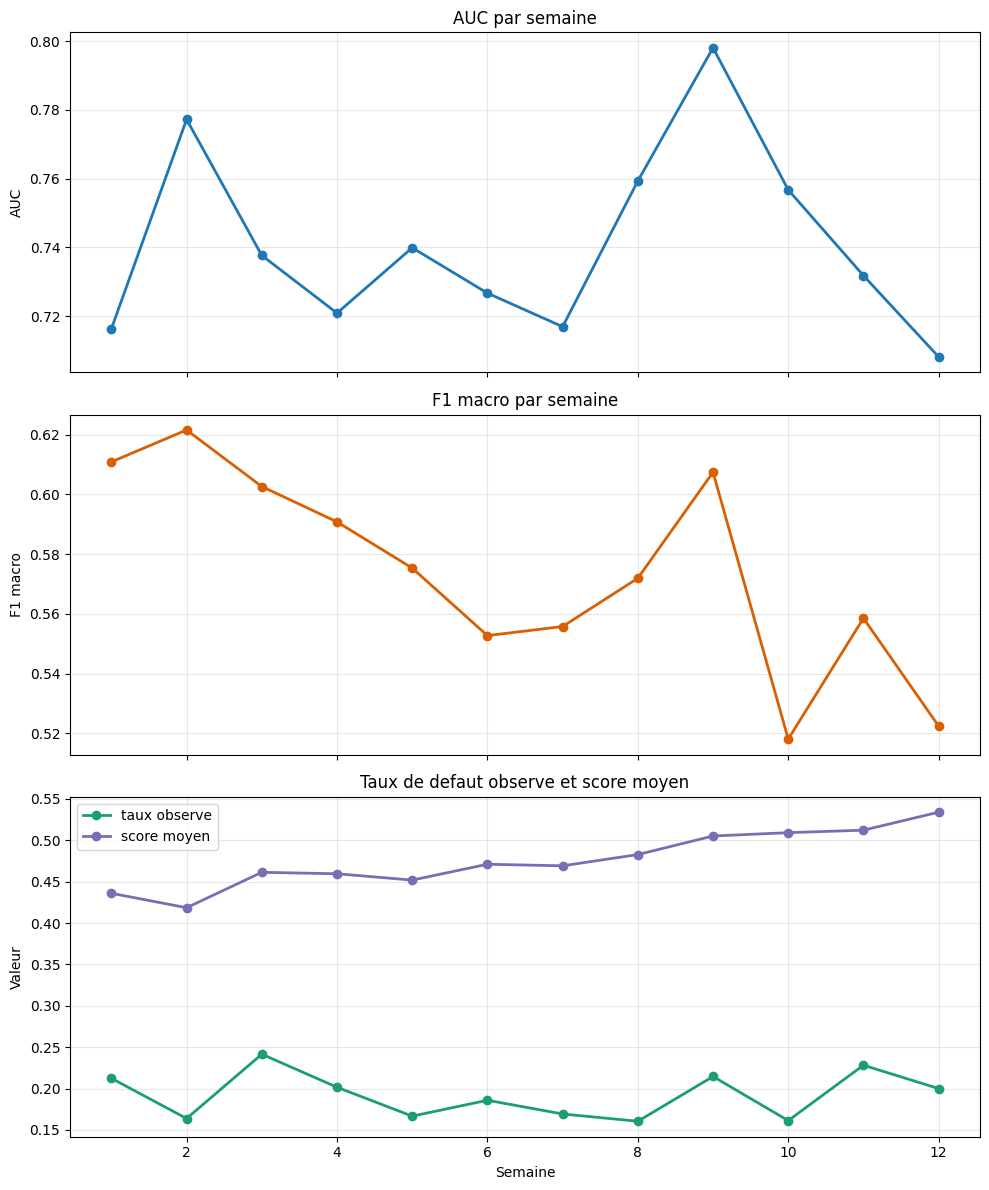

In [37]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

axes[0].plot(weekly_perf["week_index"], weekly_perf["auc"], marker="o", linewidth=2)
axes[0].set_title("AUC par semaine")
axes[0].set_ylabel("AUC")
axes[0].grid(True, alpha=0.3)

axes[1].plot(weekly_perf["week_index"], weekly_perf["f1"], marker="o", linewidth=2, color="#d95f02")
axes[1].set_title("F1 macro par semaine")
axes[1].set_ylabel("F1 macro")
axes[1].grid(True, alpha=0.3)

axes[2].plot(weekly_perf["week_index"], weekly_perf["default_rate"], marker="o", linewidth=2, color="#1b9e77", label="taux observe")
axes[2].plot(weekly_perf["week_index"], weekly_perf["mean_score"], marker="o", linewidth=2, color="#7570b3", label="score moyen")
axes[2].set_title("Taux de defaut observe et score moyen")
axes[2].set_xlabel("Semaine")
axes[2].set_ylabel("Valeur")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

L'AUC reste globalement stable sur les 12 semaines, malgré des fluctuations. Cela indique que le modèle conserve une capacité correcte à classer les bons et mauvais dossiers : il distingue encore les profils risqués des profils moins risqués.

En revanche, le F1 macro diminue nettement au fil du temps, surtout en fin de période. Cela signifie que les décisions binaires du modèle se dégradent : le seuil de décision devient probablement moins adapté aux données de production.

Le score moyen prédit augmente progressivement alors que le taux de défaut observé reste globalement stable autour de 15-25 %. Le modèle attribue donc des probabilités de défaut de plus en plus élevées sans que le risque réel augmente dans les mêmes proportions. Cela confirme le problème de calibration observé dans le reliability diagram : le modèle surestime le risque.

## 5. Diagnostic & recommandation

Voir les fichiers `diagnostic.md` & `note_recommandation_JulienD-Romain.md`